# Week 3 — Interpolation and Approximation Methods

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 5)


In [2]:
def plot_curve(f_eval, xs_data, ys_data, a, b, title, filename):
    margin = 0.25 * (b - a) if b != a else 1.0
    xs = np.linspace(a - margin, b + margin, 400)
    ys = [f_eval(x) for x in xs]
    plt.figure()
    plt.plot(xs, ys, label="interpolated/fitted")
    plt.plot(xs_data, ys_data, "ro", label="data points")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()


def print_points_table(xs, ys):
    print(f"\n{'x':>10} {'y':>10}")
    for x, y in zip(xs, ys):
        print(f"{x:>10.4f} {y:>10.4f}")


## Exercise 1 — Lagrange Polynomial Interpolation

In [3]:
def lagrange_interpolate(xs, ys, x):
    n = len(xs)
    total = 0.0
    for i in range(n):
        term = ys[i]
        for j in range(n):
            if j != i:
                term *= (x - xs[j]) / (xs[i] - xs[j])
        total += term
    return total


In [4]:
LAGRANGE_TASKS = [
    ("Dataset 1", [0, 1, 2, 3], [1, 3, 2, 5], 1.5),
    ("Dataset 2", [1, 2, 3, 4, 5], [2, 5, 10, 17, 26], 3.5),
    ("sin(x) at 0, pi/4, pi/2", [0, math.pi / 4, math.pi / 2],
     [math.sin(0), math.sin(math.pi / 4), math.sin(math.pi / 2)], math.pi / 3),
    ("e^x at 0, 0.5, 1", [0, 0.5, 1], [math.exp(0), math.exp(0.5), math.exp(1)], 0.75),
]


def run_lagrange_task(task_num=0):
    label, xs, ys, eval_x = LAGRANGE_TASKS[task_num]
    print("=" * 70)
    print(f"LAGRANGE INTERPOLATION: {label}")
    print("=" * 70)
    print_points_table(xs, ys)
    result = lagrange_interpolate(xs, ys, eval_x)
    print(f"\nP({eval_x}) = {result:.6f}")

    plot_curve(
        lambda x: lagrange_interpolate(xs, ys, x),
        xs, ys, min(xs), max(xs),
        f"Lagrange Interpolation: {label}",
        f"lagrange/lagrange_task_{task_num + 1}.png",
    )


LAGRANGE INTERPOLATION: Dataset 1

         x          y
    0.0000     1.0000
    1.0000     3.0000
    2.0000     2.0000
    3.0000     5.0000

P(1.5) = 2.437500


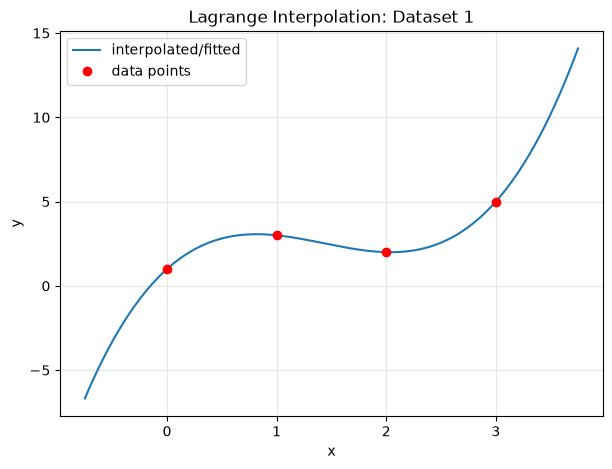

In [5]:
user_input = input("Enter task number (0-3): ").strip()
run_lagrange_task(int(user_input) if user_input else 0)


## Exercise 2 — Newton Divided Difference Interpolation

In [6]:
def newton_divided_diff(xs, ys):
    n = len(xs)
    table = [list(ys)]
    for level in range(1, n):
        prev = table[-1]
        row = [(prev[i + 1] - prev[i]) / (xs[i + level] - xs[i]) for i in range(n - level)]
        table.append(row)
    coeffs = [table[level][0] for level in range(n)]
    return coeffs, table


def newton_eval(xs, coeffs, x):
    n = len(coeffs)
    result = coeffs[-1]
    for i in range(n - 2, -1, -1):
        result = result * (x - xs[i]) + coeffs[i]
    return result


def print_divided_diff_table(xs, table):
    n = len(xs)
    header = f"{'x':>10}" + "".join(f" {'order ' + str(level):>12}" for level in range(n))
    print(f"\n{header}")
    for i in range(n):
        row = f"{xs[i]:>10.4f}"
        for level in range(n):
            row += f" {table[level][i]:>12.6f}" if i < len(table[level]) else " " * 13
        print(row)


In [7]:
NEWTON_DD_TASKS = [
    ("Dataset 1", [0, 1, 2, 3], [1, 3, 2, 5], 1.5),
    ("Dataset 2", [1, 2, 3, 4, 5], [2, 5, 10, 17, 26], 3.5),
    ("ln(x) at 1, 2, 3, 4", [1, 2, 3, 4], [math.log(1), math.log(2), math.log(3), math.log(4)], 2.5),
    ("cos(x) at 0, pi/6, pi/3, pi/2", [0, math.pi / 6, math.pi / 3, math.pi / 2],
     [math.cos(0), math.cos(math.pi / 6), math.cos(math.pi / 3), math.cos(math.pi / 2)], math.pi / 4),
]


def run_newton_dd_task(task_num=0):
    label, xs, ys, eval_x = NEWTON_DD_TASKS[task_num]
    print("=" * 70)
    print(f"NEWTON DIVIDED DIFFERENCE INTERPOLATION: {label}")
    print("=" * 70)
    print_points_table(xs, ys)
    coeffs, table = newton_divided_diff(xs, ys)
    print_divided_diff_table(xs, table)
    result = newton_eval(xs, coeffs, eval_x)
    print(f"\nP({eval_x}) = {result:.6f}")

    if task_num in (0, 1):
        lagrange_result = lagrange_interpolate(xs, ys, eval_x)
        print(f"Lagrange result for comparison: {lagrange_result:.6f} "
              f"(difference: {abs(result - lagrange_result):.2e})")

    plot_curve(
        lambda x: newton_eval(xs, coeffs, x),
        xs, ys, min(xs), max(xs),
        f"Newton Divided Difference: {label}",
        f"newton-divided/newton_dd_task_{task_num + 1}.png",
    )


NEWTON DIVIDED DIFFERENCE INTERPOLATION: Dataset 1

         x          y
    0.0000     1.0000
    1.0000     3.0000
    2.0000     2.0000
    3.0000     5.0000

         x      order 0      order 1      order 2      order 3
    0.0000     1.000000     2.000000    -1.500000     1.166667
    1.0000     3.000000    -1.000000     2.000000             
    2.0000     2.000000     3.000000                          
    3.0000     5.000000                                       

P(1.5) = 2.437500
Lagrange result for comparison: 2.437500 (difference: 0.00e+00)


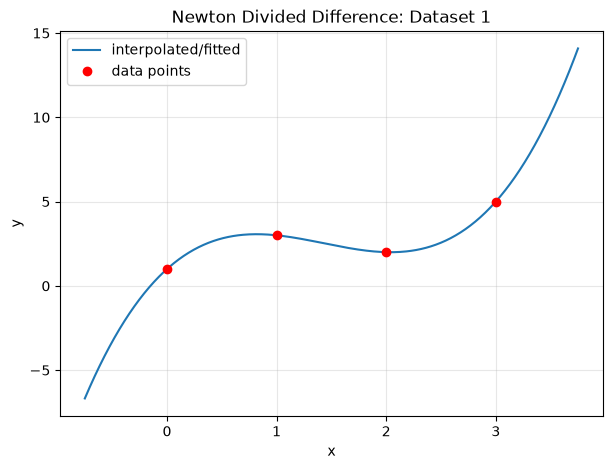

In [8]:
user_input = input("Enter task number (0-3): ").strip()
run_newton_dd_task(int(user_input) if user_input else 0)


### Forward vs. backward Newton formulas

All four Exercise 2 datasets are equally spaced, so besides the general divided-difference form we can also build the polynomial two other ways: **forward** from the first point and **backward** from the last point. Both are different arithmetic paths to the *same unique* interpolating polynomial, so evaluating all three at the same `x` is a good consistency check.

In [9]:
def finite_difference_table(ys):
    table = [list(ys)]
    while len(table[-1]) > 1:
        prev = table[-1]
        table.append([prev[i + 1] - prev[i] for i in range(len(prev) - 1)])
    return table


def newton_forward_eval(xs, ys, x):
    h = xs[1] - xs[0]
    p = (x - xs[0]) / h
    table = finite_difference_table(ys)
    n = len(xs)
    result = table[0][0]
    p_term = 1.0
    for k in range(1, n):
        p_term *= (p - k + 1)
        result += p_term * table[k][0] / math.factorial(k)
    return result


def newton_backward_eval(xs, ys, x):
    h = xs[1] - xs[0]
    q = (x - xs[-1]) / h
    table = finite_difference_table(ys)
    n = len(xs)
    result = table[0][-1]
    q_term = 1.0
    for k in range(1, n):
        q_term *= (q + k - 1)
        result += q_term * table[k][-1] / math.factorial(k)
    return result


print(f"{'Dataset':<32}{'Forward':>14}{'Backward':>14}{'Divided diff':>16}")
for label, xs, ys, eval_x in NEWTON_DD_TASKS:
    forward_value = newton_forward_eval(xs, ys, eval_x)
    backward_value = newton_backward_eval(xs, ys, eval_x)
    coeffs, _ = newton_divided_diff(xs, ys)
    divided_diff_value = newton_eval(xs, coeffs, eval_x)
    print(f"{label:<32}{forward_value:>14.6f}{backward_value:>14.6f}{divided_diff_value:>16.6f}")


Dataset                                Forward      Backward    Divided diff
Dataset 1                             2.437500      2.437500        2.437500
Dataset 2                            13.250000     13.250000       13.250000
ln(x) at 1, 2, 3, 4                   0.921221      0.921221        0.921221
cos(x) at 0, pi/6, pi/3, pi/2         0.705889      0.705889        0.705889


## Exercise 3 — Least Squares Polynomial Approximation

In [10]:
# Reused verbatim from Week 2.ipynb. Linear system via Gauss-Jordan elimination.
def gauss_jordan(matrix, rhs, verbose=False):
    augmented_matrix = np.hstack([matrix, rhs.reshape(-1, 1)]).astype(float)
    number_of_rows, number_of_columns = augmented_matrix.shape
    number_of_variables = number_of_columns - 1
    pivot_row = 0

    for column_index in range(number_of_variables):
        best_row, max_value = None, 1e-9
        for row_index in range(pivot_row, number_of_rows):
            if abs(augmented_matrix[row_index, column_index]) > max_value:
                best_row, max_value = row_index, abs(augmented_matrix[row_index, column_index])
        if best_row is None:
            continue

        augmented_matrix[[pivot_row, best_row]] = augmented_matrix[[best_row, pivot_row]]
        augmented_matrix[pivot_row] /= augmented_matrix[pivot_row, column_index]
        for row_index in range(number_of_rows):
            if row_index != pivot_row:
                augmented_matrix[row_index] -= augmented_matrix[row_index, column_index] * augmented_matrix[pivot_row]

        if verbose:
            print(f"Pivot on column {column_index + 1}:\n{np.round(augmented_matrix, 4)}\n")
        pivot_row += 1
        if pivot_row == number_of_rows:
            break

    return augmented_matrix


In [11]:
def least_squares_fit(xs, ys, degree):
    xs = np.array(xs, dtype=float)
    ys = np.array(ys, dtype=float)
    design_matrix = np.vander(xs, degree + 1, increasing=True)
    ata = design_matrix.T @ design_matrix
    aty = design_matrix.T @ ys
    reduced = gauss_jordan(ata, aty)
    return reduced[:, -1]


def polynomial_eval(coeffs, x):
    return sum(c * x ** i for i, c in enumerate(coeffs))


def sse(ys, y_hat):
    return sum((y - yh) ** 2 for y, yh in zip(ys, y_hat))


In [19]:
LEAST_SQUARES_TASKS = [
    ("Line fit", [0, 1, 2, 3, 4], [1, 2, 2, 4, 5], 1),
    ("Quadratic fit", [-2, -1, 0, 1, 2], [5, 2, 1, 2, 5], 2),
    ("Cubic fit", [0, 1, 2, 3, 4, 5], [2, 3, 5, 4, 6, 8], 3),
]


def run_least_squares_task(task_num=0):
    label, xs, ys, degree = LEAST_SQUARES_TASKS[task_num]
    print("=" * 70)
    print(f"LEAST SQUARES APPROXIMATION: {label} (degree {degree})")
    print("=" * 70)
    print_points_table(xs, ys)

    coeffs = least_squares_fit(xs, ys, degree)
    y_hat = [polynomial_eval(coeffs, x) for x in xs]
    error = sse(ys, y_hat)

    print("\nCoefficients (a0, a1, ...):", np.round(coeffs, 6))
    print(f"SSE = {error:.6f}")

    plot_curve(
        lambda x: polynomial_eval(coeffs, x),
        xs, ys, min(xs), max(xs),
        f"Least Squares Fit: {label}",
        f"least-squares/least_squares_task_{task_num + 1}.png",
    )


LEAST SQUARES APPROXIMATION: Cubic fit (degree 3)

         x          y
    0.0000     2.0000
    1.0000     3.0000
    2.0000     5.0000
    3.0000     4.0000
    4.0000     6.0000
    5.0000     8.0000

Coefficients (a0, a1, ...): [ 1.888889  2.28836  -0.813492  0.12037 ]
SSE = 1.468254


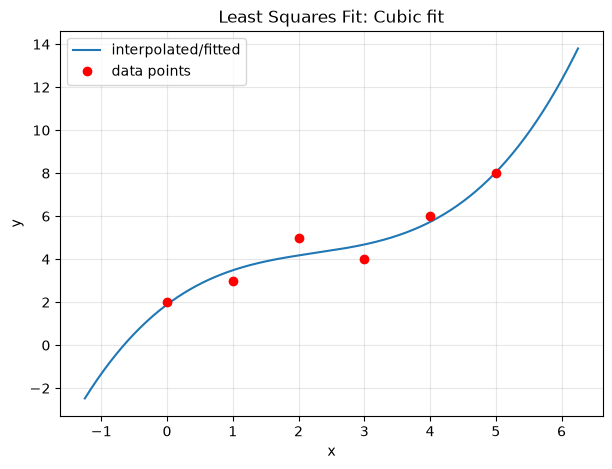

In [22]:
user_input = input("Enter task number (0-2): ").strip()
run_least_squares_task(int(user_input) if user_input else 0)


## Exercise 4 — Cubic Spline Interpolation

In [14]:
def natural_cubic_spline(xs, ys):
    n = len(xs) - 1
    h = [xs[i + 1] - xs[i] for i in range(n)]

    matrix = np.zeros((n + 1, n + 1))
    rhs = np.zeros(n + 1)
    matrix[0, 0] = 1
    matrix[n, n] = 1
    for i in range(1, n):
        matrix[i, i - 1] = h[i - 1]
        matrix[i, i] = 2 * (h[i - 1] + h[i])
        matrix[i, i + 1] = h[i]
        rhs[i] = 6 * ((ys[i + 1] - ys[i]) / h[i] - (ys[i] - ys[i - 1]) / h[i - 1])

    reduced = gauss_jordan(matrix, rhs)
    second_derivatives = reduced[:, -1]
    return second_derivatives, h


def spline_eval(xs, ys, second_derivatives, h, x):
    n = len(xs) - 1
    i = 0
    while i < n - 1 and x > xs[i + 1]:
        i += 1

    a = (xs[i + 1] - x) / h[i]
    b = (x - xs[i]) / h[i]
    m_i, m_i1 = second_derivatives[i], second_derivatives[i + 1]

    return (
        a * ys[i] + b * ys[i + 1]
        + ((a ** 3 - a) * m_i + (b ** 3 - b) * m_i1) * (h[i] ** 2) / 6
    )


In [15]:
SPLINE_TASKS = [
    ("Dataset 1", [0, 1, 2, 3, 4], [1, 2, 0, 2, 3], 2.5),
    ("Dataset 2", [1, 2, 3, 4, 5], [2, 3, 5, 4, 6], 3.5),
    ("Dataset 3", [0, 1, 2, 3, 4], [0, 1, 0, -1, 0], 1.5),
]


def run_spline_task(task_num=0):
    label, xs, ys, eval_x = SPLINE_TASKS[task_num]
    print("=" * 70)
    print(f"NATURAL CUBIC SPLINE: {label}")
    print("=" * 70)
    print_points_table(xs, ys)

    second_derivatives, h = natural_cubic_spline(xs, ys)
    result = spline_eval(xs, ys, second_derivatives, h, eval_x)
    print(f"\nSpline({eval_x}) = {result:.6f}")

    plot_curve(
        lambda x: spline_eval(xs, ys, second_derivatives, h, x),
        xs, ys, min(xs), max(xs),
        f"Natural Cubic Spline: {label}",
        f"splines/spline_task_{task_num + 1}.png",
    )


NATURAL CUBIC SPLINE: Dataset 1

         x          y
    0.0000     1.0000
    1.0000     2.0000
    2.0000     0.0000
    3.0000     2.0000
    4.0000     3.0000

Spline(2.5) = 0.691964


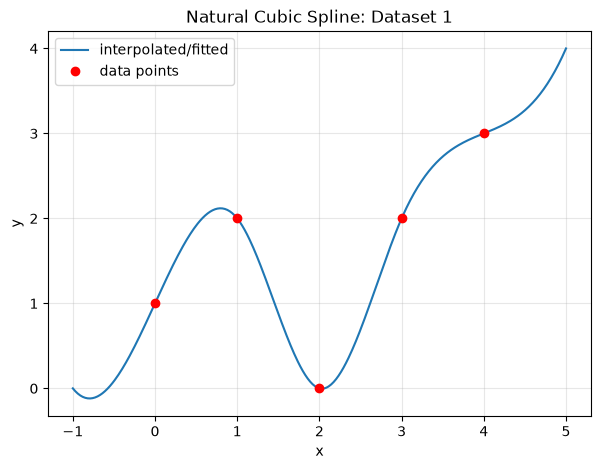

In [16]:
user_input = input("Enter task number (0-2): ").strip()
run_spline_task(int(user_input) if user_input else 0)


## Method Comparison

Evaluate Lagrange, Newton divided differences, and the natural cubic spline on the same dataset (`x = [0, 1, 2, 3]`, `y = [1, 3, 2, 5]`) at `x = 1.5`.

Comparison at x = 1.5

Method                               Value
Lagrange                          2.437500
Newton Divided Difference         2.437500
Natural Cubic Spline              2.425000


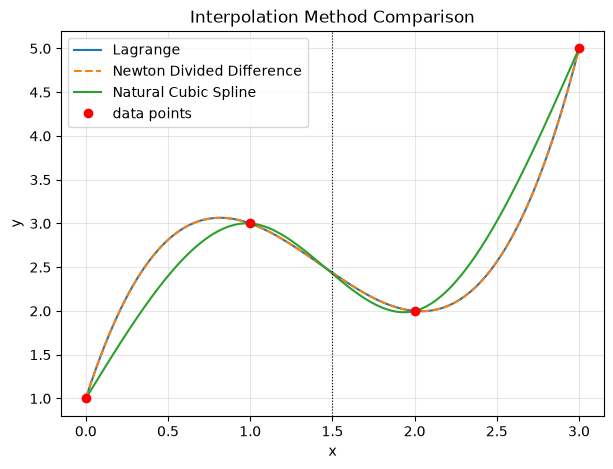

In [17]:
COMPARISON_XS = [0, 1, 2, 3]
COMPARISON_YS = [1, 3, 2, 5]
COMPARISON_X = 1.5


def run_comparison():
    lagrange_value = lagrange_interpolate(COMPARISON_XS, COMPARISON_YS, COMPARISON_X)
    coeffs, _ = newton_divided_diff(COMPARISON_XS, COMPARISON_YS)
    newton_value = newton_eval(COMPARISON_XS, coeffs, COMPARISON_X)
    second_derivatives, h = natural_cubic_spline(COMPARISON_XS, COMPARISON_YS)
    spline_value = spline_eval(COMPARISON_XS, COMPARISON_YS, second_derivatives, h, COMPARISON_X)

    results = {
        "Lagrange": lagrange_value,
        "Newton Divided Difference": newton_value,
        "Natural Cubic Spline": spline_value,
    }

    print("=" * 70)
    print(f"Comparison at x = {COMPARISON_X}")
    print("=" * 70)
    print(f"\n{'Method':<28}{'Value':>14}")
    for name, value in results.items():
        print(f"{name:<28}{value:>14.6f}")

    plt.figure()
    xs_dense = np.linspace(min(COMPARISON_XS), max(COMPARISON_XS), 400)
    plt.plot(xs_dense, [lagrange_interpolate(COMPARISON_XS, COMPARISON_YS, x) for x in xs_dense], label="Lagrange")
    plt.plot(xs_dense, [newton_eval(COMPARISON_XS, coeffs, x) for x in xs_dense], "--", label="Newton Divided Difference")
    plt.plot(xs_dense, [spline_eval(COMPARISON_XS, COMPARISON_YS, second_derivatives, h, x) for x in xs_dense],
             label="Natural Cubic Spline")
    plt.plot(COMPARISON_XS, COMPARISON_YS, "ro", label="data points")
    plt.axvline(COMPARISON_X, color="black", linewidth=0.8, linestyle=":")
    plt.title("Interpolation Method Comparison")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig("interpolation_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


run_comparison()


## Verification Against Reference Implementations

Cross-check the manual algorithms against NumPy's own polynomial fitting (`np.polyfit`/`np.polyval`) for Lagrange, Newton divided differences and least squares. The natural cubic spline is checked against its own interpolation property (it must reproduce the original data points exactly).

In [18]:
def verify_polynomial_interpolation(xs, ys, eval_x, our_value, label):
    reference_coeffs = np.polyfit(xs, ys, len(xs) - 1)
    reference_value = np.polyval(reference_coeffs, eval_x)
    print(f"{label}")
    print(f"  reference (np.polyfit + np.polyval): {reference_value:.6f}")
    print(f"  our value:                           {our_value:.6f}")
    print(f"  abs difference:                       {abs(our_value - reference_value):.2e}\n")


def verify_least_squares(xs, ys, degree, our_coeffs, label):
    reference_coeffs = np.polyfit(xs, ys, degree)[::-1]
    print(f"{label}")
    print(f"  reference (np.polyfit) coeffs (a0..an): {np.round(reference_coeffs, 6)}")
    print(f"  our coeffs (a0..an):                    {np.round(our_coeffs, 6)}")
    print(f"  max abs difference:                     {np.max(np.abs(our_coeffs - reference_coeffs)):.2e}\n")


def verify_spline_interpolation_property(xs, ys, second_derivatives, h, label):
    residuals = [abs(spline_eval(xs, ys, second_derivatives, h, x) - y) for x, y in zip(xs, ys)]
    print(f"{label}")
    print(f"  max |spline(x_i) - y_i| at original data points: {max(residuals):.2e}\n")


print("=" * 70)
print("Lagrange interpolation vs np.polyfit")
print("=" * 70)
for label, xs, ys, eval_x in LAGRANGE_TASKS:
    verify_polynomial_interpolation(xs, ys, eval_x, lagrange_interpolate(xs, ys, eval_x), label)

print("=" * 70)
print("Newton divided differences vs np.polyfit")
print("=" * 70)
for label, xs, ys, eval_x in NEWTON_DD_TASKS:
    coeffs, _ = newton_divided_diff(xs, ys)
    verify_polynomial_interpolation(xs, ys, eval_x, newton_eval(xs, coeffs, eval_x), label)

print("=" * 70)
print("Least squares fit vs np.polyfit")
print("=" * 70)
for label, xs, ys, degree in LEAST_SQUARES_TASKS:
    verify_least_squares(xs, ys, degree, least_squares_fit(xs, ys, degree), label)

print("=" * 70)
print("Natural cubic spline — interpolation property")
print("=" * 70)
for label, xs, ys, eval_x in SPLINE_TASKS:
    second_derivatives, h = natural_cubic_spline(xs, ys)
    verify_spline_interpolation_property(xs, ys, second_derivatives, h, label)


Lagrange interpolation vs np.polyfit
Dataset 1
  reference (np.polyfit + np.polyval): 2.437500
  our value:                           2.437500
  abs difference:                       5.77e-15

Dataset 2
  reference (np.polyfit + np.polyval): 13.250000
  our value:                           13.250000
  abs difference:                       1.07e-14

sin(x) at 0, pi/4, pi/2
  reference (np.polyfit + np.polyval): 0.850762
  our value:                           0.850762
  abs difference:                       6.66e-16

e^x at 0, 0.5, 1
  reference (np.polyfit + np.polyval): 2.130897
  our value:                           2.130897
  abs difference:                       4.44e-16

Newton divided differences vs np.polyfit
Dataset 1
  reference (np.polyfit + np.polyval): 2.437500
  our value:                           2.437500
  abs difference:                       5.77e-15

Dataset 2
  reference (np.polyfit + np.polyval): 13.250000
  our value:                           13.250000
  abs diffe